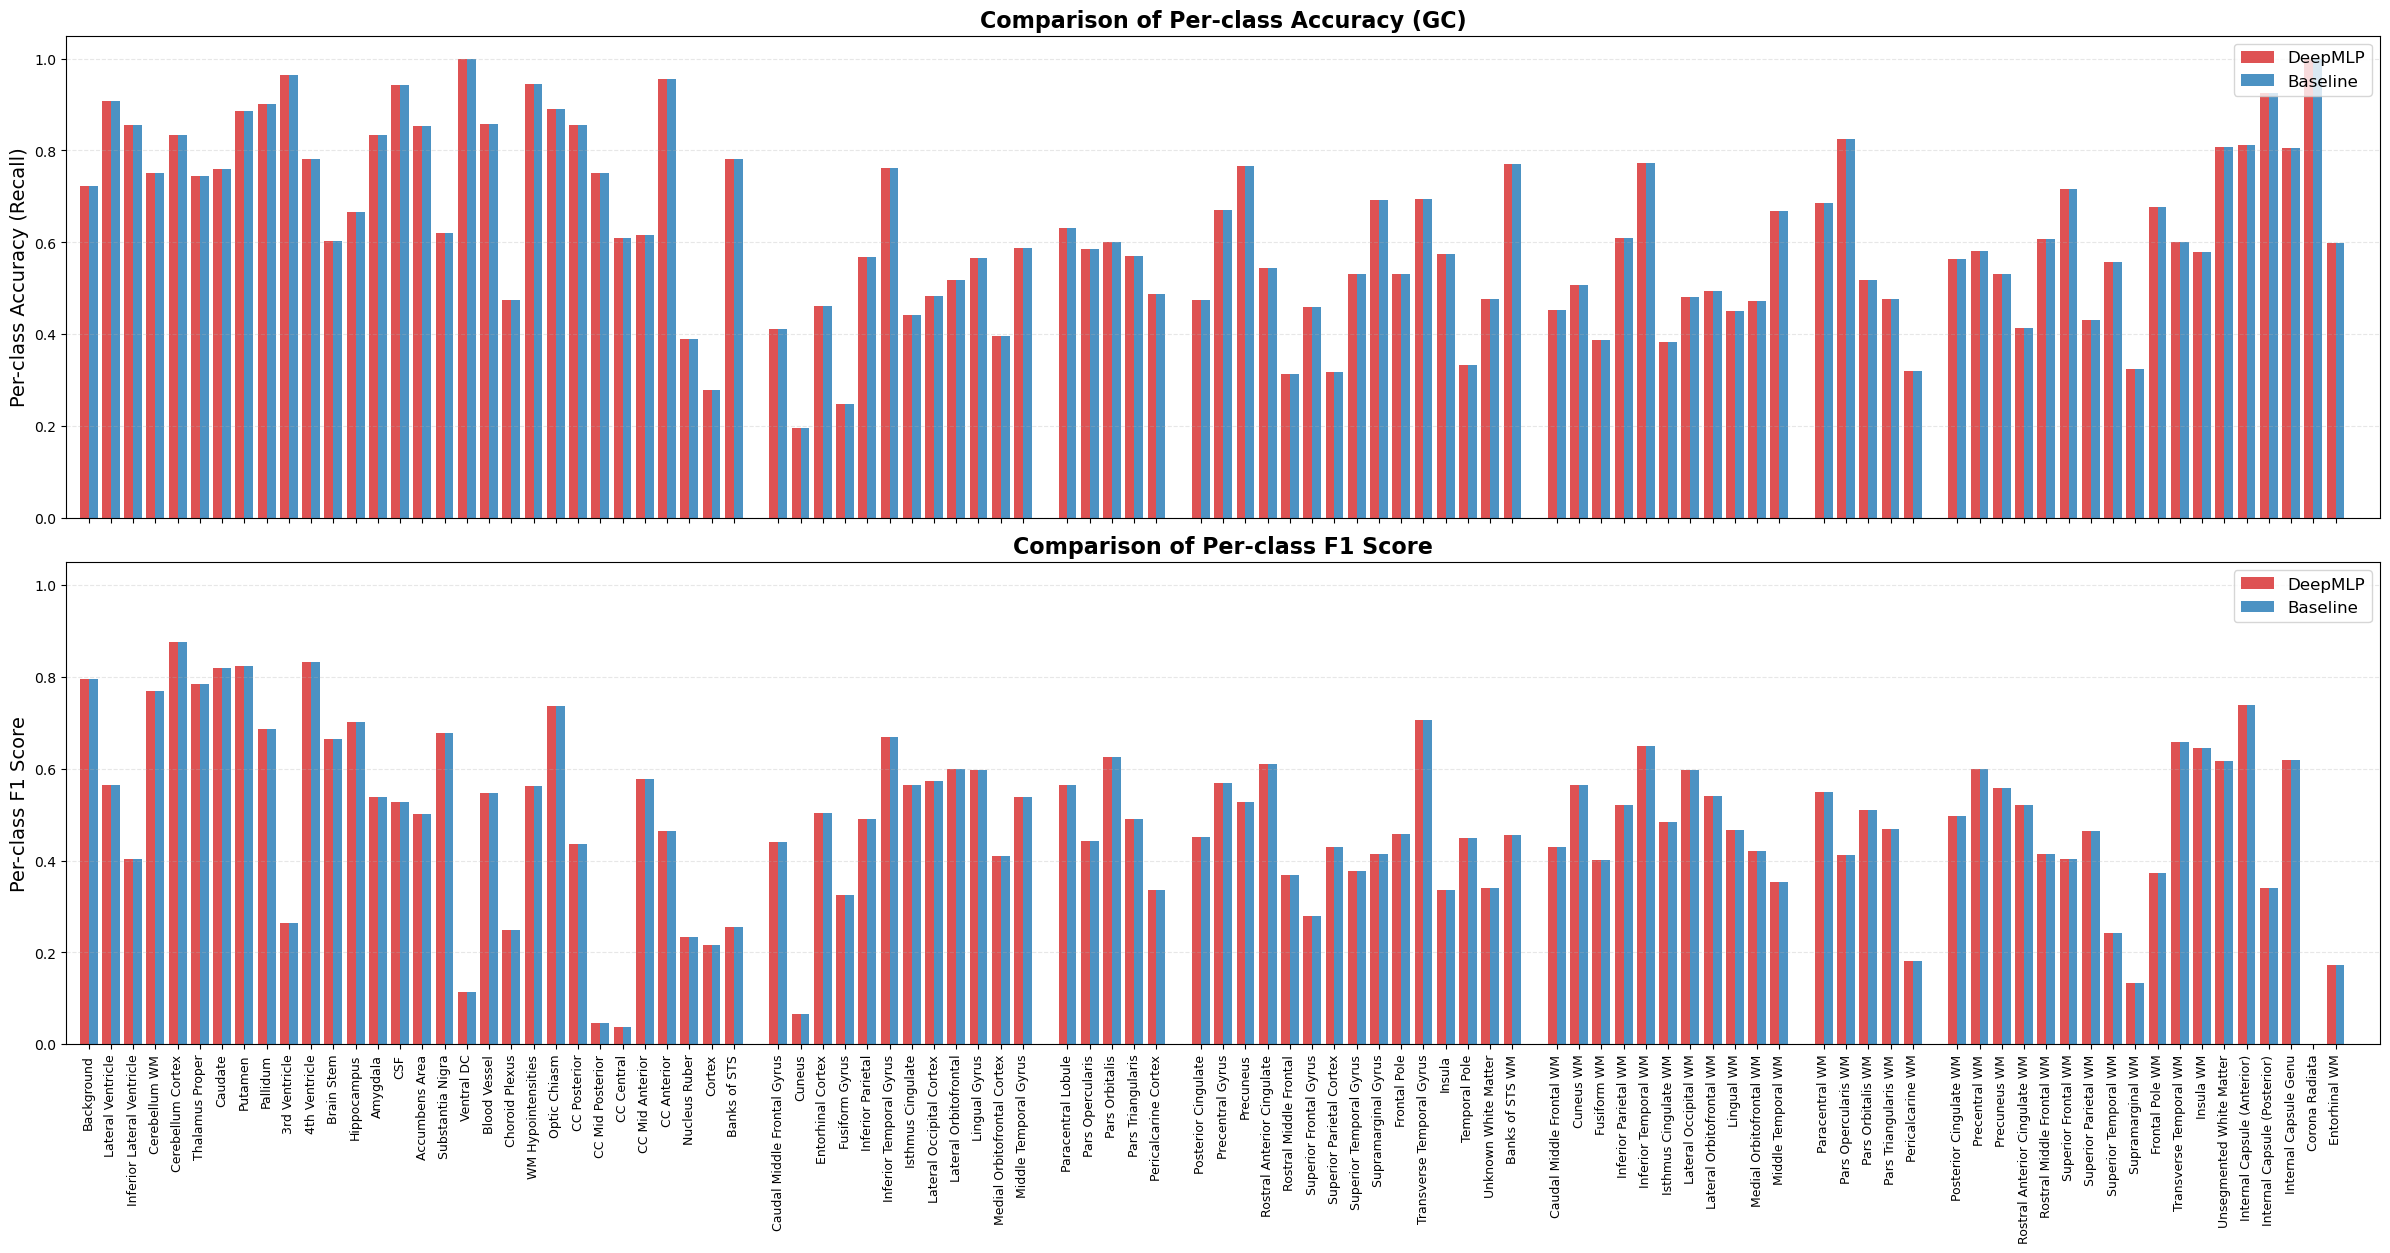

图表已生成: fig3_4_comparison_named.png


In [7]:
import re
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. 完整的解剖学名称字典 (基于你的 Manual Override + CSV 补全清洗)
# ---------------------------------------------------------
class_names = {
    # --- Subcortical & General ---
    0: "Background",
    1: "Lateral Ventricle",
    2: "Inferior Lateral Ventricle",
    3: "Cerebellum WM",
    4: "Cerebellum Cortex",
    5: "Thalamus Proper",
    6: "Caudate",
    7: "Putamen",
    8: "Pallidum",
    9: "3rd Ventricle",
    10: "4th Ventricle",
    11: "Brain Stem",
    12: "Hippocampus",
    13: "Amygdala",
    14: "CSF",
    15: "Accumbens Area",
    16: "Substantia Nigra",
    17: "Ventral DC",
    18: "Blood Vessel",
    19: "Choroid Plexus",
    20: "WM Hypointensities",
    21: "Optic Chiasm",
    22: "CC Posterior",
    23: "CC Mid Posterior",
    24: "CC Central",
    25: "CC Mid Anterior",
    26: "CC Anterior",
    27: "Nucleus Ruber",
    
    # --- Cortex (Grey Matter) ---
    28: "Cortex",
    29: "Banks of STS",
    30: "Caudal Anterior Cingulate",
    31: "Caudal Middle Frontal Gyrus",
    32: "Cuneus",
    33: "Entorhinal Cortex",
    34: "Fusiform Gyrus",
    35: "Inferior Parietal",
    36: "Inferior Temporal Gyrus",
    37: "Isthmus Cingulate",
    38: "Lateral Occipital Cortex",
    39: "Lateral Orbitofrontal",
    40: "Lingual Gyrus",
    41: "Medial Orbitofrontal Cortex",
    42: "Middle Temporal Gyrus",
    43: "Parahippocampal Gyrus",
    44: "Paracentral Lobule",
    45: "Pars Opercularis",
    46: "Pars Orbitalis",
    47: "Pars Triangularis",
    48: "Pericalcarine Cortex",
    49: "Postcentral Gyrus",
    50: "Posterior Cingulate",
    51: "Precentral Gyrus",
    52: "Precuneus",
    53: "Rostral Anterior Cingulate",
    54: "Rostral Middle Frontal",
    55: "Superior Frontal Gyrus",
    56: "Superior Parietal Cortex",
    57: "Superior Temporal Gyrus",
    58: "Supramarginal Gyrus",
    59: "Frontal Pole",
    60: "Transverse Temporal Gyrus",
    61: "Insula",
    62: "Temporal Pole",
    
    # --- White Matter (Subcortical & Deep) ---
    63: "Unknown White Matter",
    64: "Banks of STS WM",
    65: "Caudal Anterior Cingulate WM",
    66: "Caudal Middle Frontal WM",
    67: "Cuneus WM",
    68: "Fusiform WM",
    69: "Inferior Parietal WM",
    70: "Inferior Temporal WM",
    71: "Isthmus Cingulate WM",
    72: "Lateral Occipital WM",
    73: "Lateral Orbitofrontal WM",
    74: "Lingual WM",
    75: "Medial Orbitofrontal WM",
    76: "Middle Temporal WM",
    77: "Parahippocampal WM",
    78: "Paracentral WM",
    79: "Pars Opercularis WM",
    80: "Pars Orbitalis WM",
    81: "Pars Triangularis WM",
    82: "Pericalcarine WM",
    83: "Postcentral WM",
    84: "Posterior Cingulate WM",
    85: "Precentral WM",
    86: "Precuneus WM",
    87: "Rostral Anterior Cingulate WM",
    88: "Rostral Middle Frontal WM",
    89: "Superior Frontal WM",
    90: "Superior Parietal WM",
    91: "Superior Temporal WM",
    92: "Supramarginal WM",
    93: "Frontal Pole WM",
    94: "Transverse Temporal WM",
    95: "Insula WM",
    96: "Unsegmented White Matter",
    97: "Internal Capsule (Anterior)",
    98: "Internal Capsule (Posterior)",
    99: "Internal Capsule Genu",
    100: "Corona Radiata",
    101: "Entorhinal WM"
}

# ---------------------------------------------------------
# 2. 数据解析与绘图代码
# ---------------------------------------------------------

# 文件路径 (请修改为你本地的实际路径)
file_path = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/deepmlptest_evaluation_report.txt'


def parse_report_full(filename):
    data = {'ids': [], 'recall': [], 'f1': []}
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            text = f.read()
        start_marker = "每个类别的详细指标:"
        idx = text.find(start_marker)
        if idx != -1:
            table_text = text[idx:]
            # 正则匹配: ID, Count, Precision, Recall, F1
            pattern = re.compile(r"^\s*(\d+)\s+\d+\s+[0-9\.]+\S*\s+([0-9\.]+)\S*\s+([0-9\.]+)", re.MULTILINE)
            matches = pattern.findall(table_text)
            for pid, rec, f1 in matches:
                data['ids'].append(int(pid))
                data['recall'].append(float(rec))
                data['f1'].append(float(f1))
    except FileNotFoundError:
        print(f"错误: 找不到文件 {filename}")
        return {}
    return data

# 加载数据
deepmlp_data = parse_report_full(file_path)

if not deepmlp_data:
    print("未能读取数据。")
else:
    # 占位符 Baseline 数据 (复制 DeepMLP，实际请替换为真实 Baseline 文件读取)
    baseline_data = deepmlp_data.copy() 

    # 准备绘图数据
    ids = np.array(deepmlp_data['ids'])
    # 将 ID 映射为名字列表
    names = [class_names.get(i, str(i)) for i in ids]
    
    width = 0.4
    
    # 设置超宽画布以容纳 102 个名字
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 14), sharex=True)
    
    # --- 上图: Per-class GC (Recall) ---
    ax1.bar(ids - width/2, deepmlp_data['recall'], width, label='DeepMLP', color='#d62728', alpha=0.8)
    ax1.bar(ids + width/2, baseline_data['recall'], width, label='Baseline', color='#1f77b4', alpha=0.8)
    
    ax1.set_ylabel('Per-class Accuracy (Recall)', fontsize=14)
    ax1.set_title('Comparison of Per-class Accuracy (GC)', fontsize=16, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.set_ylim(0, 1.05)
    # 移除上图的 X 轴刻度标签，避免重复
    plt.setp(ax1.get_xticklabels(), visible=False)

    # --- 下图: Per-class F1 Score ---
    ax2.bar(ids - width/2, deepmlp_data['f1'], width, label='DeepMLP', color='#d62728', alpha=0.8)
    ax2.bar(ids + width/2, baseline_data['f1'], width, label='Baseline', color='#1f77b4', alpha=0.8)

    ax2.set_ylabel('Per-class F1 Score', fontsize=14)
    ax2.set_title('Comparison of Per-class F1 Score', fontsize=16, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=12)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.set_ylim(0, 1.05)
    
    # 设置 X 轴: 显示所有 102 个名字，旋转 90 度
    ax2.set_xticks(ids)
    ax2.set_xticklabels(names, rotation=90, fontsize=9, ha='center')
    ax2.set_xlim(-1, 103)

    plt.tight_layout()
    # 调整底部边距，给名字留出足够空间
    plt.subplots_adjust(bottom=0.25)
    
    save_path = 'fig3_4_comparison_named.png'
    # plt.savefig(save_path, dpi=300)
    plt.show()
    
    print(f"图表已生成: {save_path}")